In [1]:
import numpy as np
import pandas as pd
df_fea = pd.read_csv('fea.csv')
df_target = pd.read_csv('target.csv')
df_fea


,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b2fb64-26ad-4c44-9373-758ef3761740,0,5000,4.9,7.3,32.2,55.6,7,1.7,13.4,Medium,Moderate,5,10.0,2.98
4996,708e9ce1-193f-415e-a1f1-8bbe6528cec1,28,4000,6.1,10.6,33.9,28.8,7,4.9,6.4,Low,Good,5,10.0,3.60
4997,6ce90202-2b2a-46e8-b313-936f2b5f32da,21,4500,7.5,12.1,35.8,50.7,3,3.0,16.6,Medium,Good,6,10.0,3.93
4998,a289b415-2c3e-4cea-b987-6224987f4b1b,15,4500,5.0,7.1,29.5,88.5,4,0.7,8.2,Medium,Good,7,10.0,2.28


In [2]:
df_target

,Device_ID,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,67.2,Replace Battery
...,...,...,...
4995,39b2fb64-26ad-4c44-9373-758ef3761740,89.1,Keep Using
4996,708e9ce1-193f-415e-a1f1-8bbe6528cec1,50.8,Replace Battery
4997,6ce90202-2b2a-46e8-b313-936f2b5f32da,51.2,Replace Battery
4998,a289b415-2c3e-4cea-b987-6224987f4b1b,78.1,Keep Using


In [103]:
df_fea.isna().sum()

Device_ID                           0
device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
dtype: int64

In [8]:
df_target.isna().sum()

Device_ID                         0
current_battery_health_percent    0
recommended_action                0
dtype: int64

In [3]:
df_fea = df_fea.drop(columns=['Device_ID'], axis=1)


In [4]:
df_fea

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04
1,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23
2,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21
3,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13
4,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,5000,4.9,7.3,32.2,55.6,7,1.7,13.4,Medium,Moderate,5,10.0,2.98
4996,28,4000,6.1,10.6,33.9,28.8,7,4.9,6.4,Low,Good,5,10.0,3.60
4997,21,4500,7.5,12.1,35.8,50.7,3,3.0,16.6,Medium,Good,6,10.0,3.93
4998,15,4500,5.0,7.1,29.5,88.5,4,0.7,8.2,Medium,Good,7,10.0,2.28


In [106]:
df_fea.columns

Index(['device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index'],
      dtype='object')

In [19]:
df_fea['background_app_usage_level'].value_counts()

background_app_usage_level
Low       1707
Medium    1684
High      1609
Name: count, dtype: int64

In [11]:

df_fea['signal_strength_avg'].value_counts()

signal_strength_avg
Good        3025
Moderate    1509
Poor         466
Name: count, dtype: int64

In [5]:
df_fea['background_app_usage_level'] = df_fea['background_app_usage_level'].map({'High': 2, 'Medium': 1, 'Low': 0}).astype(float)
df_fea['signal_strength_avg'] = df_fea['signal_strength_avg'].map({'Good': 2,'Moderate': 1, 'Poor': 0}).astype(float)
df_fea

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,1.0,0.0,4,10.0,4.04
1,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,1.0,2.0,7,10.0,4.23
2,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,1.0,2.0,6,10.0,2.21
3,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,1.0,2.0,8,10.0,3.13
4,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,2.0,2.0,5,10.0,4.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,5000,4.9,7.3,32.2,55.6,7,1.7,13.4,1.0,1.0,5,10.0,2.98
4996,28,4000,6.1,10.6,33.9,28.8,7,4.9,6.4,0.0,2.0,5,10.0,3.60
4997,21,4500,7.5,12.1,35.8,50.7,3,3.0,16.6,1.0,2.0,6,10.0,3.93
4998,15,4500,5.0,7.1,29.5,88.5,4,0.7,8.2,1.0,2.0,7,10.0,2.28


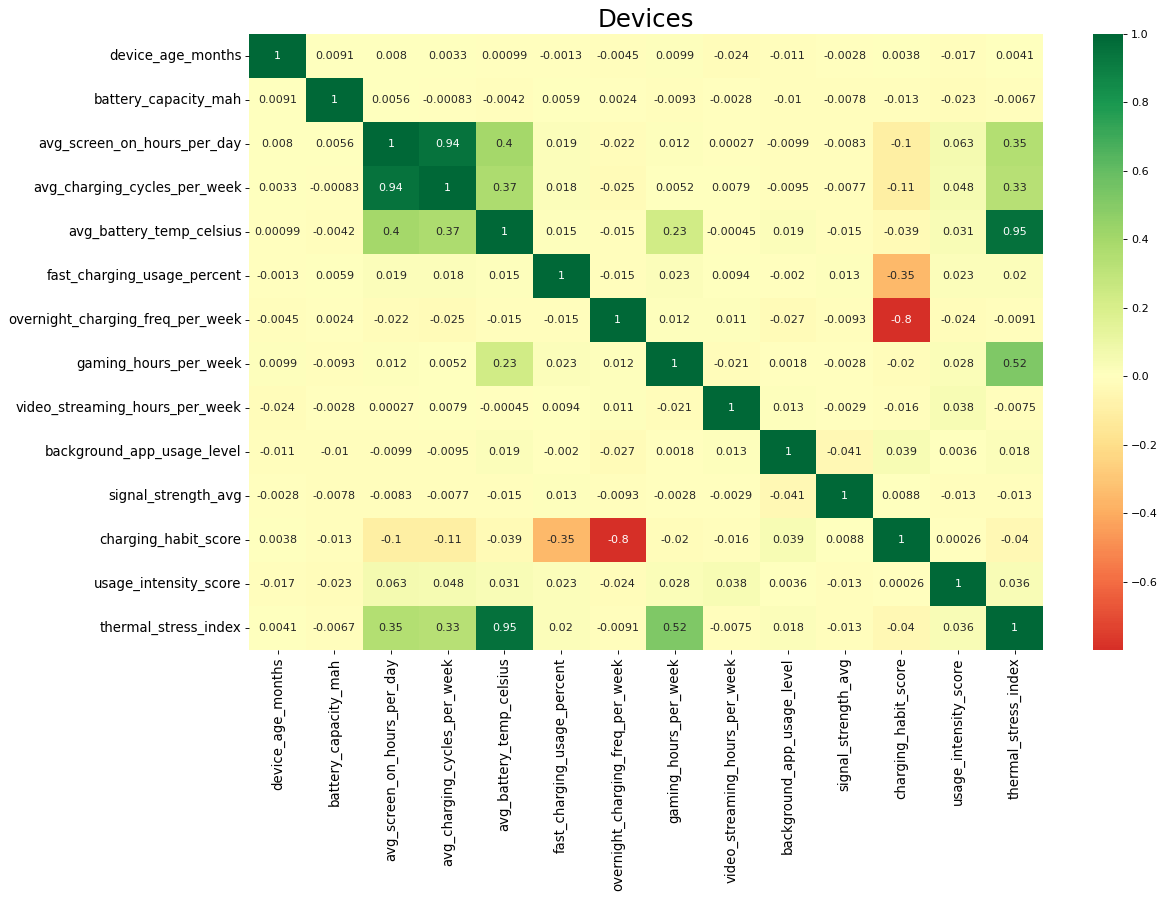

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
heatdf  = df_fea

plt.figure(figsize=(16,10), dpi= 80)
sns.heatmap(heatdf.corr(), xticklabels=heatdf.corr().columns, yticklabels=heatdf.corr().columns, cmap='RdYlGn', center=0, annot=True)

plt.title('Devices', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [7]:
df_target = df_target.drop(columns=['Device_ID'], axis=1)

In [8]:
df_target['recommended_action'].value_counts()

recommended_action
Replace Battery    2325
Keep Using         1440
Change Phone       1235
Name: count, dtype: int64

In [9]:
df_target['recommended_action'] = df_target['recommended_action'].map({'Keep Using': 2,'Change Phone': 0, 'Replace Battery': 1}).astype(float)
df_target

,current_battery_health_percent,recommended_action
0,32.8,0.0
1,50.3,1.0
2,66.1,1.0
3,46.8,0.0
4,67.2,1.0
...,...,...
4995,89.1,2.0
4996,50.8,1.0
4997,51.2,1.0
4998,78.1,2.0


In [10]:
df_target = df_target.drop(columns=['current_battery_health_percent'], axis=1)


In [26]:
df_target.shape

(5000, 1)

In [11]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor

In [13]:
from sklearn.model_selection import train_test_split

In [33]:
X = df_fea.to_numpy()
y = df_target.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state = 42, test_size = 0.2)

In [78]:
train_features = torch.FloatTensor(X_train)
train_targets = torch.LongTensor(y_train).squeeze()
test_features = torch.FloatTensor(X_test)
test_targets = torch.LongTensor(y_test)

In [79]:
t

tensor([[2.6000e+01, 4.5000e+03, 8.9000e+00,  ..., 7.0000e+00, 1.0000e+01,
         4.4500e+00],
        [4.3000e+01, 5.0000e+03, 9.9000e+00,  ..., 8.0000e+00, 1.0000e+01,
         3.2800e+00],
        [1.2000e+01, 5.0000e+03, 4.5000e+00,  ..., 6.0000e+00, 1.0000e+01,
         2.0400e+00],
        ...,
        [2.0000e+01, 5.0000e+03, 4.5000e+00,  ..., 8.0000e+00, 1.0000e+01,
         3.3700e+00],
        [4.4000e+01, 5.0000e+03, 5.7000e+00,  ..., 7.0000e+00, 1.0000e+01,
         3.1100e+00],
        [1.2000e+01, 4.5000e+03, 8.9000e+00,  ..., 4.0000e+00, 1.0000e+01,
         4.0800e+00]])

tensor([[1],
        [0],
        [2],
        ...,
        [1],
        [0],
        [1]])

In [80]:
batch = 64
train_loader = DataLoader(
    TensorDataset(train_features, train_targets), 
    batch_size = batch, 
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(test_features, test_targets), 
    batch_size = batch, 
    shuffle=False 
)

In [81]:
class modeltorch(nn.Module):
    def __init__(self, input_size = train_features.shape[1], hidden_size = 64, num_classes = 3):
        super(modeltorch, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)

        return out

model = modeltorch()

num_epochs = 5
learning_rate = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [87]:
def train(dataloader,model,criterion):
    step = len(train_loader)
    num_epoch = 5
    for epoch in range(num_epoch):
        for i, (batch, label) in enumerate(train_loader):
            outputs = model(batch)
            loss = criterion(outputs, label)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))
        

In [89]:
train(train_loader,model,criterion)

Epoch [1/5], Loss: 1.1327
Epoch [2/5], Loss: 1.0306
Epoch [3/5], Loss: 1.1108
Epoch [4/5], Loss: 1.0200
Epoch [5/5], Loss: 1.1170


In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for i, (batch, label) in enumerate(train_loader):
            outputs = model(batch)
            loss = criterion(outputs, label)
            test_loss += loss_fn(outputs, label).item()
            correct += (outputs.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [111]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score



model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())  # переносим на CPU и превращаем в numpy
        all_labels.extend(labels.cpu().numpy())

# Расчет метрик
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')  # взвешенный F1, подходит для мульткласса

print(f"\nТочность: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")


Точность: 0.4700
F1-score: 0.3005
